In [28]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [29]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/amd/amd_data.csv')

In [30]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2009-03-31,3.050000,1177.0,-416.0,9052.0,9215.0,-163.0,-3.23,0.15
1,1,2009-06-30,3.870000,1184.0,-330.0,8683.0,9148.0,-465.0,-3.98,0.16
2,2,2009-09-30,5.660000,1396.0,-128.0,8747.0,9316.0,-569.0,-3.13,0.12
3,3,2009-12-31,9.680000,1646.0,1178.0,9078.0,8430.0,648.0,0.11,0.11
4,4,2010-03-31,9.270000,1574.0,257.0,5232.0,4436.0,796.0,1.75,0.20
...,...,...,...,...,...,...,...,...,...,...
61,61,2024-06-30,162.210007,5835.0,265.0,67886.0,11348.0,56538.0,3.04,5.33
62,62,2024-09-30,164.080002,6819.0,771.0,69636.0,12651.0,56985.0,2.72,4.83
63,63,2024-12-31,120.790001,7658.0,482.0,69226.0,11658.0,57568.0,2.53,4.33
64,64,2025-03-31,102.739998,7438.0,709.0,71550.0,13669.0,57881.0,1.99,4.33


In [31]:
# create column assets_liabilities_ratio
#data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop unnecessary columns
data = data.drop(columns=['Unnamed: 0'])

In [32]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
40,2019-03-31,25.520000,1272.0,16.0,4931.0,3143.0,1788.0,1.93,2.42
41,2019-06-30,30.370001,1531.0,35.0,5102.0,3201.0,1901.0,2.24,2.40
42,2019-09-30,28.990000,1801.0,120.0,5253.0,3077.0,2176.0,2.80,1.83
43,2019-12-31,45.860001,2127.0,170.0,6028.0,3201.0,2827.0,3.35,1.55
44,2020-03-31,45.480000,1786.0,162.0,5864.0,2827.0,3037.0,1.28,0.05
45,2020-06-30,52.610001,1932.0,157.0,6583.0,3278.0,3305.0,-7.50,0.09
46,2020-09-30,81.989998,2801.0,390.0,7023.0,3156.0,3867.0,-1.41,0.09
47,2020-12-31,91.709999,3244.0,1781.0,8962.0,3125.0,5837.0,-1.02,0.09
48,2021-03-31,78.500000,3445.0,555.0,10047.0,3570.0,6477.0,1.76,0.07
49,2021-06-30,93.930000,3850.0,710.0,10691.0,3626.0,7065.0,12.24,0.10


In [33]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 4    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd",  "share_holder_equity_musd", "gdp_growth", "interest_rate"]
# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
n = len(df)

# exponential weights: more recent quarters get larger weight
K=8
weights = np.exp(np.linspace(-K, 0, n))  
weights /= weights.sum()  # normalize to sum to 1

for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr = df[col].pct_change()
    growth_rates[col] = np.average(gr.dropna(), weights=weights[1:])  # skip first NaN


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
#future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15946/3768486357.py:46: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [34]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-03-31,3.050000,1177.000000,-416.000000,9052.000000,9215.000000,-163.000000,-3.23,0.15
1,2009-06-30,3.870000,1184.000000,-330.000000,8683.000000,9148.000000,-465.000000,-3.98,0.16
2,2009-09-30,5.660000,1396.000000,-128.000000,8747.000000,9316.000000,-569.000000,-3.13,0.12
3,2009-12-31,9.680000,1646.000000,1178.000000,9078.000000,8430.000000,648.000000,0.11,0.11
4,2010-03-31,9.270000,1574.000000,257.000000,5232.000000,4436.000000,796.000000,1.75,0.20
...,...,...,...,...,...,...,...,...,...
65,2025-06-30,141.899994,7685.000000,872.000000,74820.000000,15155.000000,59665.000000,1.99,4.33
66,2025-09-30,NaN,8075.464827,1222.073935,84356.195001,16193.559581,69842.140985,1.99,4.33
67,2025-12-31,NaN,8485.768662,1712.688878,95107.827252,17303.290790,81755.210883,1.99,4.33
68,2026-03-31,NaN,8916.919501,2400.266555,107229.810502,18489.070957,95700.309474,1.99,4.33


In [35]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
n_bt = len(df_bt)

# exponential weights: more recent quarters get larger weight
K=8
weights_bt = np.exp(np.linspace(4, 0, n_bt))  
weights_bt /= weights_bt.sum()  # normalize to sum to 1

for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr_bt = df_bt[col].pct_change()
    growth_rates_bt[col] = np.average(gr_bt.dropna(), weights=weights_bt[1:])  # skip first NaN

# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "total_assets_musd","total_liabilities_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr_bt) ** i for i in range(1, FUTURE_PERIODS+1)]

# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15946/2442392108.py:41: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [36]:
weights_bt

array([0.06457776, 0.060479  , 0.0566404 , 0.05304543, 0.04967863,
       0.04652553, 0.04357255, 0.040807  , 0.03821698, 0.03579134,
       0.03351967, 0.03139217, 0.02939971, 0.02753371, 0.02578614,
       0.02414949, 0.02261673, 0.02118124, 0.01983687, 0.01857782,
       0.01739868, 0.01629439, 0.01526018, 0.01429162, 0.01338453,
       0.01253501, 0.01173941, 0.01099431, 0.0102965 , 0.00964298,
       0.00903094, 0.00845775, 0.00792094, 0.00741819, 0.00694736,
       0.00650641, 0.00609345, 0.0057067 , 0.00534449, 0.00500528,
       0.00468759, 0.00439007, 0.00411143, 0.00385048, 0.00360609,
       0.00337721, 0.00316286, 0.00296211, 0.00277411, 0.00259803,
       0.00243314, 0.00227871, 0.00213408, 0.00199863, 0.00187177,
       0.00175297, 0.00164171, 0.00153751, 0.00143993, 0.00134853,
       0.00126294, 0.00118278])

In [37]:
future_full

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-03-31,3.050000,1177.000000,-416.000000,9052.000000,9215.000000,-163.000000,-3.23,0.15
1,2009-06-30,3.870000,1184.000000,-330.000000,8683.000000,9148.000000,-465.000000,-3.98,0.16
2,2009-09-30,5.660000,1396.000000,-128.000000,8747.000000,9316.000000,-569.000000,-3.13,0.12
3,2009-12-31,9.680000,1646.000000,1178.000000,9078.000000,8430.000000,648.000000,0.11,0.11
4,2010-03-31,9.270000,1574.000000,257.000000,5232.000000,4436.000000,796.000000,1.75,0.20
...,...,...,...,...,...,...,...,...,...
65,2025-06-30,141.899994,7685.000000,872.000000,74820.000000,15155.000000,59665.000000,1.99,4.33
66,2025-09-30,NaN,8075.464827,1222.073935,84356.195001,16193.559581,69842.140985,1.99,4.33
67,2025-12-31,NaN,8485.768662,1712.688878,95107.827252,17303.290790,81755.210883,1.99,4.33
68,2026-03-31,NaN,8916.919501,2400.266555,107229.810502,18489.070957,95700.309474,1.99,4.33


In [38]:
growth_rates_bt

{'revenue_musd': np.float64(0.022670103178857752),
 'net_income_musd': np.float64(-1.5313334760859345),
 'total_assets_musd': np.float64(-0.016077450958127897),
 'total_liabilities_musd': np.float64(-0.03480748513594401),
 'share_holder_equity_musd': np.float64(-0.07335136295570323)}

In [39]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



19:56:04 - cmdstanpy - INFO - Chain [1] start processing
19:56:05 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
58 2023-09-30  104.084491   82.891922  124.888258  102.820000
59 2023-12-31  129.430079  109.603765  150.220596  147.410004
60 2024-03-31  123.573037  101.882809  143.690963  180.490005
61 2024-06-30  127.629328  107.693255  150.202776  162.210007
62 2024-09-30  152.637356  131.005900  172.690562  164.080002
63 2024-12-31  144.001963  121.747655  164.726103  120.790001
64 2025-03-31  155.742409  135.066830  177.236122  102.739998
65 2025-06-30  158.925631  138.937594  180.025024  141.899994
66 2025-09-30  167.972751  145.749654  187.615519         NaN
67 2025-12-31  173.933283  152.666900  194.924286         NaN
68 2026-03-31  194.115618  172.635872  214.333087         NaN
69 2026-06-30  215.793772  194.214273  237.141444         NaN


In [40]:
predict_df

,ds,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,2009-03-31,1177.000000,-416.000000,9052.000000,9215.000000,-163.000000,-3.23,0.15
1,2009-06-30,1184.000000,-330.000000,8683.000000,9148.000000,-465.000000,-3.98,0.16
2,2009-09-30,1396.000000,-128.000000,8747.000000,9316.000000,-569.000000,-3.13,0.12
3,2009-12-31,1646.000000,1178.000000,9078.000000,8430.000000,648.000000,0.11,0.11
4,2010-03-31,1574.000000,257.000000,5232.000000,4436.000000,796.000000,1.75,0.20
...,...,...,...,...,...,...,...,...
65,2025-06-30,7685.000000,872.000000,74820.000000,15155.000000,59665.000000,1.99,4.33
66,2025-09-30,8075.464827,1222.073935,84356.195001,16193.559581,69842.140985,1.99,4.33
67,2025-12-31,8485.768662,1712.688878,95107.827252,17303.290790,81755.210883,1.99,4.33
68,2026-03-31,8916.919501,2400.266555,107229.810502,18489.070957,95700.309474,1.99,4.33


In [41]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

19:56:05 - cmdstanpy - INFO - Chain [1] start processing
19:56:05 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
54 2022-09-30   88.043405   70.407946  105.080790   63.360001
55 2022-12-31  103.250865   85.947872  121.735962   64.769997
56 2023-03-31   96.948446   80.255414  114.657375   98.010002
57 2023-06-30  100.700173   82.894039  118.425292  113.910004
58 2023-09-30  113.826906   97.425627  130.322406  102.820000
59 2023-12-31  137.640890  121.238943  154.907460  147.410004
60 2024-03-31  135.774496  118.611498  153.598830  180.490005
61 2024-06-30  139.289282  121.589541  156.553493  162.210007
62 2024-09-30  136.011756  118.093887  154.241410         NaN
63 2024-12-31  142.846178  124.426401  161.253110         NaN
64 2025-03-31  159.363098  141.946017  176.891560         NaN
65 2025-06-30  160.064635  142.166866  176.586153         NaN


In [42]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 11.713041051678788
RMSE: 274.020897202707
R²: 0.8940751421263412
           ds        yhat  yhat_lower  yhat_upper           y  is_future
58 2023-09-30  104.084491   82.891922  124.888258  102.820000      False
59 2023-12-31  129.430079  109.603765  150.220596  147.410004      False
60 2024-03-31  123.573037  101.882809  143.690963  180.490005      False
61 2024-06-30  127.629328  107.693255  150.202776  162.210007      False
62 2024-09-30  152.637356  131.005900  172.690562  164.080002      False
63 2024-12-31  144.001963  121.747655  164.726103  120.790001      False
64 2025-03-31  155.742409  135.066830  177.236122  102.739998      False
65 2025-06-30  158.925631  138.937594  180.025024  141.899994      False
66 2025-09-30  167.972751  145.749654  187.615519         NaN       True
67 2025-12-31  173.933283  152.666900  194.924286         NaN       True
68 2026-03-31  194.115618  172.635872  214.333087         NaN       True
69 2026-06-30  215.793772  194.214273  237.141444     

In [43]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 9.700610231576837
RMSE: 188.64831868905122
R²: 0.9125154218376441
           ds        yhat  yhat_lower  yhat_upper           y  is_future
54 2022-09-30   88.043405   70.407946  105.080790   63.360001      False
55 2022-12-31  103.250865   85.947872  121.735962   64.769997      False
56 2023-03-31   96.948446   80.255414  114.657375   98.010002      False
57 2023-06-30  100.700173   82.894039  118.425292  113.910004      False
58 2023-09-30  113.826906   97.425627  130.322406  102.820000      False
59 2023-12-31  137.640890  121.238943  154.907460  147.410004      False
60 2024-03-31  135.774496  118.611498  153.598830  180.490005      False
61 2024-06-30  139.289282  121.589541  156.553493  162.210007      False
62 2024-09-30  136.011756  118.093887  154.241410         NaN       True
63 2024-12-31  142.846178  124.426401  161.253110         NaN       True
64 2025-03-31  159.363098  141.946017  176.891560         NaN       True
65 2025-06-30  160.064635  142.166866  176.586153    

In [44]:
#5) Compare the actuall y with the yhat prediction for the backtesting period
comparison = data[["ds", "y"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner")
comparison["absolute error"] = (comparison["y"] - comparison["yhat"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["y"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds           y        yhat  absolute error relative error
54 2022-09-30   63.360001   88.043405       24.683404          39.0%
55 2022-12-31   64.769997  103.250865       38.480868          59.4%
56 2023-03-31   98.010002   96.948446        1.061556           1.1%
57 2023-06-30  113.910004  100.700173       13.209831          11.6%
58 2023-09-30  102.820000  113.826906       11.006907          10.7%
59 2023-12-31  147.410004  137.640890        9.769114           6.6%
60 2024-03-31  180.490005  135.774496       44.715510          24.8%
61 2024-06-30  162.210007  139.289282       22.920725          14.1%
62 2024-09-30  164.080002  136.011756       28.068246          17.1%
63 2024-12-31  120.790001  142.846178       22.056177          18.3%
64 2025-03-31  102.739998  159.363098       56.623100          55.1%
65 2025-06-30  141.899994  160.064635       18.164641          12.8%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15946/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


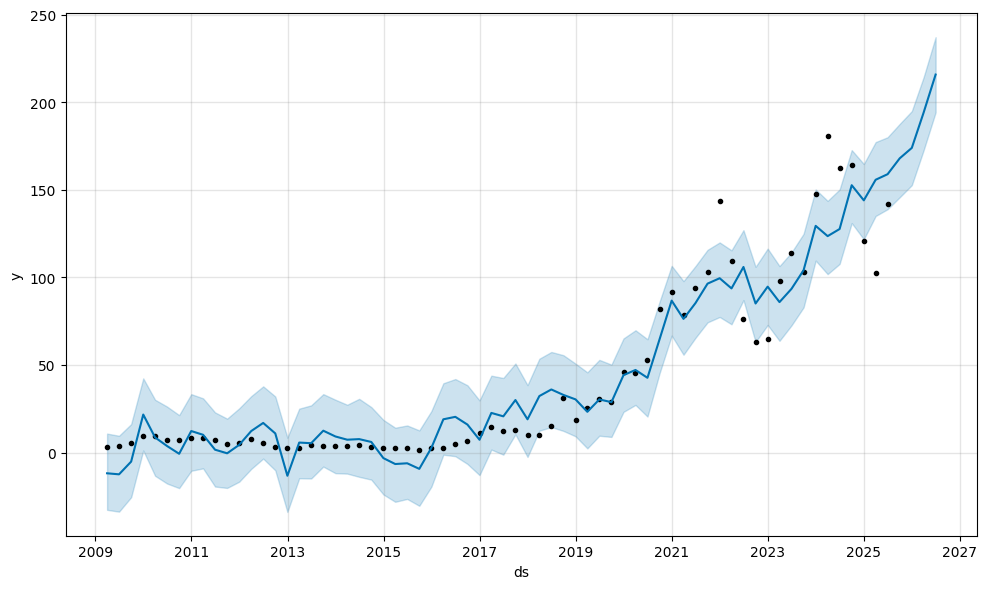

In [45]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [46]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.837505,0.796292,0.469865,0.718871,0.527516,0.743219,0.268059,0.734807
y,0.837505,1.000000,0.902378,0.608214,0.806945,0.689830,0.817603,0.217541,0.713681
revenue_musd,0.796292,0.902378,1.000000,0.549763,0.938960,0.852406,0.942874,0.211476,0.755382
net_income_musd,0.469865,0.608214,0.549763,1.000000,0.340044,0.276560,0.346947,0.165499,0.182999
total_assets_musd,0.718871,0.806945,0.938960,0.340044,1.000000,0.941879,0.998354,0.111473,0.842381
total_liabilities_musd,0.527516,0.689830,0.852406,0.276560,0.941879,1.000000,0.921063,-0.050115,0.756844
share_holder_equity_musd,0.743219,0.817603,0.942874,0.346947,0.998354,0.921063,1.000000,0.137766,0.847239
gdp_growth,0.268059,0.217541,0.211476,0.165499,0.111473,-0.050115,0.137766,1.000000,0.138662
interest_rate,0.734807,0.713681,0.755382,0.182999,0.842381,0.756844,0.847239,0.138662,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15946/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


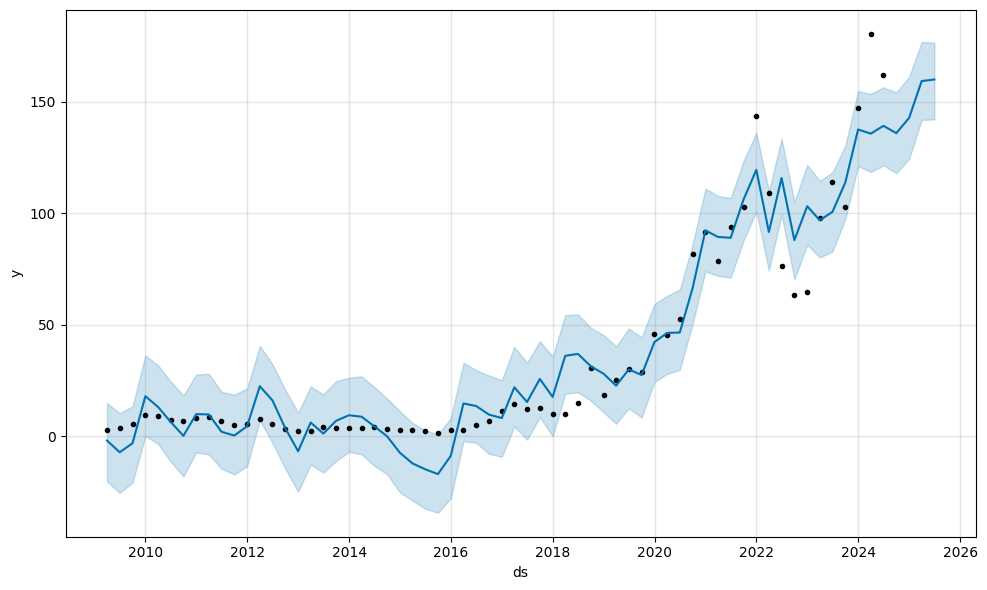

In [47]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

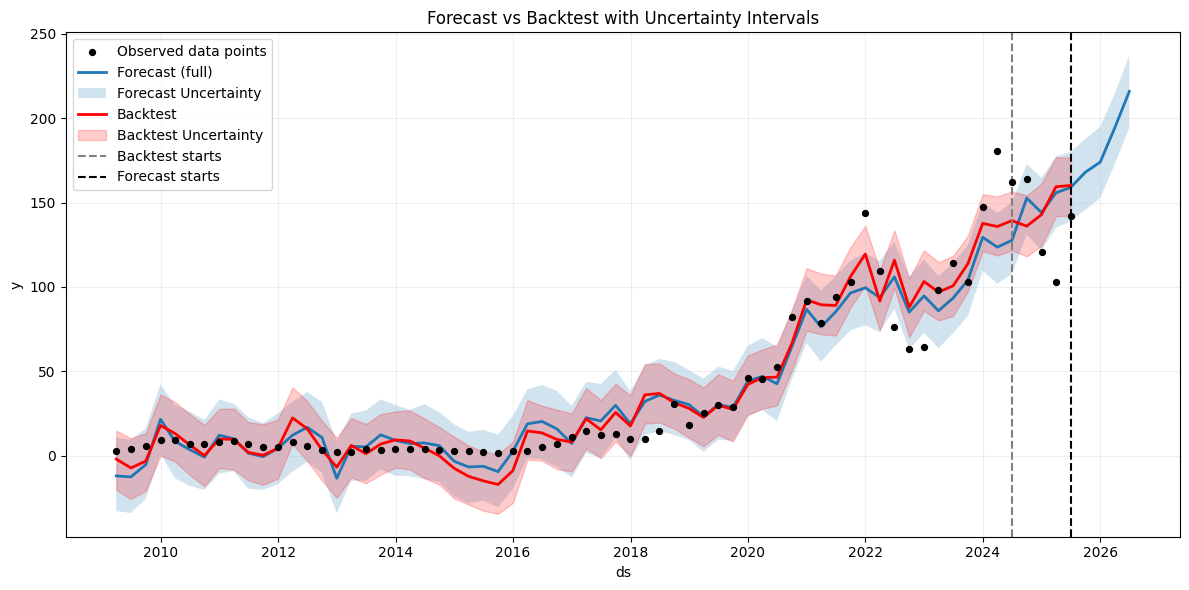

In [48]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'].eq(False), 'ds'].max()   # ~2024-06-30
full_split = results.loc[results['is_future'].eq(False), 'ds'].max()         # ~2025-06-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [49]:
results

,ds,yhat,yhat_lower,yhat_upper,y,is_future
0,2009-03-31,-11.806336,-32.666490,10.853735,3.050000,False
1,2009-06-30,-12.399650,-33.710800,9.603716,3.870000,False
2,2009-09-30,-5.135876,-25.463818,16.269487,5.660000,False
3,2009-12-31,21.722805,1.220457,42.380629,9.680000,False
4,2010-03-31,8.668158,-13.234636,30.158888,9.270000,False
...,...,...,...,...,...,...
65,2025-06-30,158.925631,138.937594,180.025024,141.899994,False
66,2025-09-30,167.972751,145.749654,187.615519,NaN,True
67,2025-12-31,173.933283,152.666900,194.924286,NaN,True
68,2026-03-31,194.115618,172.635872,214.333087,NaN,True
